In [4]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import handy.my_utils as deniz
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# df = pd.read_csv('Epileptic Seizure Recognition.csv')
CHB_MIT_PATH = 'data-understanding/data/chb-mit'

In [6]:
print("=" * 60)
print("📊 PARSING ALL PATIENT ANNOTATIONS")
print("=" * 60)

# Parse all patients
all_annotations = {}
patient_dirs = sorted([d for d in os.listdir(CHB_MIT_PATH)
                       if os.path.isdir(os.path.join(CHB_MIT_PATH, d))
                       and d.startswith('chb')])

total_seizures = 0
total_files_with_seizures = 0

print(f"\n👥 Processing {len(patient_dirs)} patients...\n")

for patient in patient_dirs:
    patient_path = os.path.join(CHB_MIT_PATH, patient)
    summary_file = os.path.join(patient_path, f'{patient}-summary.txt')

    if os.path.exists(summary_file):
        seizure_info = deniz.parse_summary_file(summary_file)

        if seizure_info:
            all_annotations[patient] = seizure_info
            n_files = len(seizure_info)
            n_seizures = sum(len(times) for times in seizure_info.values())
            total_files_with_seizures += n_files
            total_seizures += n_seizures

            print(f"   ✓ {patient}: {n_files} files, {n_seizures} seizures")
        else:
            print(f"   - {patient}: No seizures found")
    else:
        print(f"   ✗ {patient}: No summary file")

print("\n" + "-" * 60)
print(f"📈 TOTAL SUMMARY:")
print(f"   • Patients with seizures: {len(all_annotations)}")
print(f"   • Files with seizures: {total_files_with_seizures}")
print(f"   • Total seizure events: {total_seizures}")
print("-" * 60)

# Show example
print("\n📋 Example - chb01 seizure times:")
if 'chb01' in all_annotations:
    for filename, times in list(all_annotations['chb01'].items())[:3]:
        print(f"   {filename}: {times}")

print("\n" + "=" * 60)
print("✅ All annotations parsed!")
print("=" * 60)

📊 PARSING ALL PATIENT ANNOTATIONS

👥 Processing 24 patients...

   ✓ chb01: 7 files, 7 seizures
   ✓ chb02: 3 files, 3 seizures
   ✓ chb03: 7 files, 7 seizures
   ✓ chb04: 3 files, 4 seizures
   ✓ chb05: 5 files, 5 seizures
   ✓ chb06: 7 files, 10 seizures
   ✓ chb07: 3 files, 3 seizures
   ✓ chb08: 5 files, 5 seizures
   ✓ chb09: 3 files, 4 seizures
   ✓ chb10: 7 files, 7 seizures
   ✓ chb11: 3 files, 3 seizures
   ✓ chb12: 13 files, 40 seizures
   ✓ chb13: 8 files, 12 seizures
   ✓ chb14: 7 files, 8 seizures
   ✓ chb15: 14 files, 20 seizures
   ✓ chb16: 6 files, 10 seizures
   ✓ chb17: 3 files, 3 seizures
   ✓ chb18: 6 files, 6 seizures
   ✓ chb19: 3 files, 3 seizures
   ✓ chb20: 6 files, 8 seizures
   ✓ chb21: 4 files, 4 seizures
   ✓ chb22: 3 files, 3 seizures
   ✓ chb23: 3 files, 7 seizures
   ✓ chb24: 12 files, 16 seizures

------------------------------------------------------------
📈 TOTAL SUMMARY:
   • Patients with seizures: 24
   • Files with seizures: 141
   • Total seizure

In [7]:
all_annotations['chb12']

{'chb12_06.edf': [(1665, 1726), (3415, 3447)],
 'chb12_08.edf': [(1426, 1439), (1591, 1614), (1957, 1977), (2798, 2824)],
 'chb12_09.edf': [(3082, 3114), (3503, 3535)],
 'chb12_10.edf': [(593, 625), (811, 856)],
 'chb12_11.edf': [(1085, 1122)],
 'chb12_23.edf': [(253, 333), (425, 522), (630, 670)],
 'chb12_27.edf': [(916, 951),
  (1097, 1124),
  (1728, 1753),
  (1921, 1963),
  (2388, 2440),
  (2621, 2669)],
 'chb12_28.edf': [(181, 215)],
 'chb12_29.edf': [(107, 146),
  (554, 592),
  (1163, 1199),
  (1401, 1447),
  (1884, 1921),
  (3557, 3584)],
 'chb12_33.edf': [(2185, 2206), (2427, 2450)],
 'chb12_36.edf': [(653, 680)],
 'chb12_38.edf': [(1548, 1573),
  (2798, 2821),
  (2966, 3009),
  (3146, 3201),
  (3364, 3410)],
 'chb12_42.edf': [(699, 750),
  (945, 973),
  (1170, 1199),
  (1676, 1701),
  (2213, 2236)]}

In [8]:
patient_dirs

['chb01',
 'chb02',
 'chb03',
 'chb04',
 'chb05',
 'chb06',
 'chb07',
 'chb08',
 'chb09',
 'chb10',
 'chb11',
 'chb12',
 'chb13',
 'chb14',
 'chb15',
 'chb16',
 'chb17',
 'chb18',
 'chb19',
 'chb20',
 'chb21',
 'chb22',
 'chb23',
 'chb24']

In [9]:
patient_path

'data-understanding/data/chb-mit\\chb24'

In [10]:
!pip install pyedflib mne pywavelets -q

You should consider upgrading via the 'C:\Users\gorse\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [11]:
import pyedflib
import mne
from scipy import signal
from scipy.signal import butter, filtfilt, welch
from scipy.stats import skew, kurtosis
import pywt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [12]:
print("\n📋 Library versions:")
print(f"   • NumPy: {np.__version__}")
print(f"   • Pandas: {pd.__version__}")
print(f"   • MNE: {mne.__version__}")



📋 Library versions:
   • NumPy: 2.1.3
   • Pandas: 2.2.3
   • MNE: 1.10.1


In [13]:
# ============================================
# CELL 5: Install Required Libraries
# ============================================

print("=" * 60)
print("📦 INSTALLING REQUIRED LIBRARIES")
print("=" * 60)

# Install EEG processing libraries
!pip install pyedflib mne pywavelets -q

print("\n✅ Libraries installed!")

# Import everything we'll need for the ENTIRE pipeline
import pyedflib
import mne
from scipy import signal
from scipy.signal import butter, filtfilt, welch
from scipy.stats import skew, kurtosis
import pywt
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# For deep learning (later)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, precision_recall_curve,
                             f1_score, accuracy_score, precision_score, recall_score)

# Suppress warnings
import warnings

warnings.filterwarnings('ignore')
mne.set_log_level('ERROR')

print("✅ All libraries imported!")

# Verify
print("\n📋 Library versions:")
print(f"   • NumPy: {np.__version__}")
print(f"   • Pandas: {pd.__version__}")
print(f"   • MNE: {mne.__version__}")
print(f"   • TensorFlow: {tf.__version__}")

# Check GPU
print("\n🖥️ GPU Status:")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"   ✅ GPU Available: {gpus[0].name}")
    # Enable memory growth
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("   ⚠️ No GPU found - Training will be slower")
    print("   💡 Tip: Settings → Accelerator → GPU")

print("\n" + "=" * 60)
print("✅ Ready to load EEG data!")
print("=" * 60)

✅ All libraries imported!

📋 Library versions:
   • NumPy: 2.1.3
   • Pandas: 2.2.3
   • MNE: 1.10.1
   • TensorFlow: 2.19.0

🖥️ GPU Status:
   ⚠️ No GPU found - Training will be slower
   💡 Tip: Settings → Accelerator → GPU

✅ Ready to load EEG data!


In [14]:
print("=" * 60)
print("👁️ LOADING & VISUALIZING EEG DATA")
print("=" * 60)

# Load a file WITH seizure (chb01_03.edf has seizure at 2996-3036 seconds)
sample_file = os.path.join(CHB_MIT_PATH, 'chb01', 'chb01_03.edf')
seizure_start = 2996  # seconds
seizure_end = 3036  # seconds

print(f"\n📂 Loading: chb01_03.edf")
print(f"   🚨 Seizure: {seizure_start}s - {seizure_end}s")

signals, channel_names, fs = deniz.load_edf_file(sample_file)

if signals is not None:
    print(f"\n📊 File Information:")
    print(f"   • Channels: {len(channel_names)}")
    print(f"   • Sampling Rate: {fs} Hz")
    print(f"   • Duration: {signals.shape[1] / fs:.1f} seconds ({signals.shape[1] / fs / 60:.1f} minutes)")
    print(f"   • Total samples: {signals.shape[1]:,}")

    print(f"\n📋 Channel Names:")
    for i, name in enumerate(channel_names[:8]):
        print(f"   {i + 1}. {name}")
    print(f"   ... and {len(channel_names) - 8} more")

print("\n" + "=" * 60)
print("✅ EEG file loaded successfully!")
print("=" * 60)


📊 File Information:
   • Channels: 23
   • Sampling Rate: 256 Hz
   • Duration: 3600.0 seconds (60.0 minutes)
   • Total samples: 921,600

📋 Channel Names:
   1. FP1-F7
   2. F7-T7
   3. T7-P7
   4. P7-O1
   5. FP1-F3
   6. F3-C3
   7. C3-P3
   8. P3-O1
   ... and 15 more

✅ EEG file loaded successfully!


In [15]:
fs

256

In [16]:
print(signals)

[[-17.77777778   0.1953602    0.1953602  ... -17.77777778  -8.79120879
   -4.88400488]
 [ 39.26739927   0.1953602    0.1953602  ... -23.24786325 -22.46642247
  -20.51282051]
 [ -3.71184371   0.1953602    0.1953602  ...  59.19413919  60.36630037
   59.19413919]
 ...
 [ -9.18192918   0.1953602    0.1953602  ...  48.64468864  27.93650794
   12.6984127 ]
 [-39.65811966   0.1953602    0.1953602  ...  43.56532357  38.48595849
   36.14163614]
 [-59.97557998   0.1953602    0.1953602  ...  19.34065934  26.37362637
   32.23443223]]


# Visualize seizure vs. non-seizure

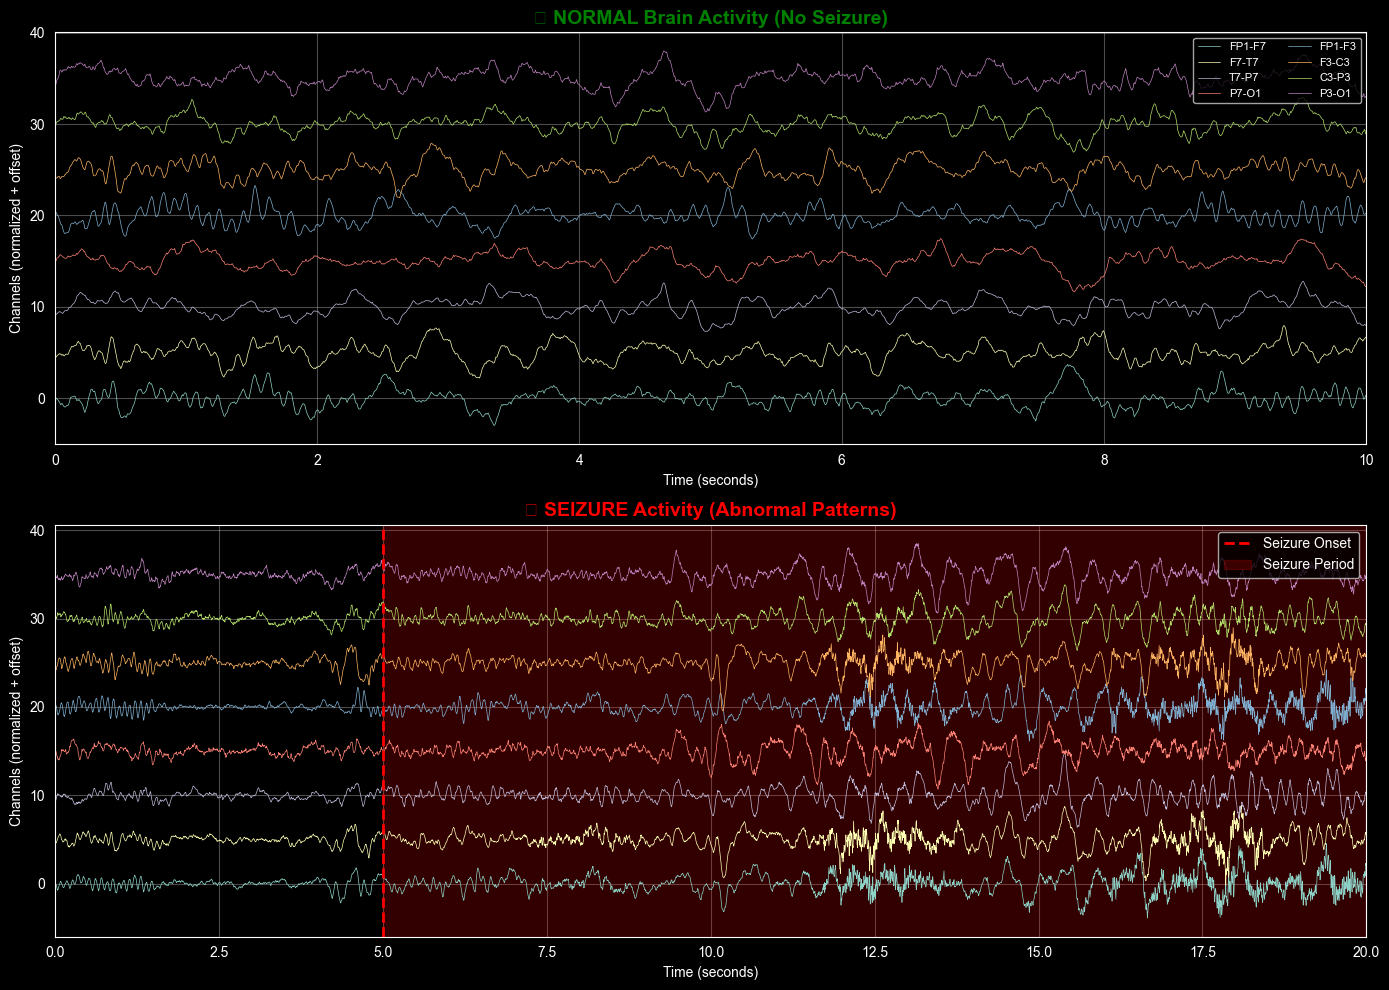

In [31]:
print("=" * 60)
print("📈 VISUALIZING NORMAL vs SEIZURE ACTIVITY")
print("=" * 60)

# Select channels to display (first 8 for clarity)
n_display_channels = 8

# Define time windows (in seconds)
normal_start = 1000  # Normal period
normal_end = 1010  # 10 seconds of normal

seizure_vis_start = seizure_start - 5  # 5 sec before seizure
seizure_vis_end = seizure_start + 15  # 15 sec into seizure

# Convert to samples
normal_start_samp = normal_start * fs
normal_end_samp = normal_end * fs
seizure_start_samp = seizure_vis_start * fs
seizure_end_samp = seizure_vis_end * fs

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ===== Plot 1: Normal Activity =====
ax1 = axes[0]
time_normal = np.arange(normal_end_samp - normal_start_samp) / fs

for i in range(n_display_channels):
    # Normalize and offset for visibility
    signal_segment = signals[i, normal_start_samp:normal_end_samp]
    signal_norm = (signal_segment - np.mean(signal_segment)) / (np.std(signal_segment) + 1e-8)
    ax1.plot(time_normal, signal_norm + i * 5, linewidth=0.5, label=channel_names[i])

ax1.set_title('🧠 NORMAL Brain Activity (No Seizure)', fontsize=14, fontweight='bold', color='green')
ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Channels (normalized + offset)')
ax1.set_xlim(0, 10)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=8, ncol=2)

# ===== Plot 2: Seizure Activity =====
ax2 = axes[1]
time_seizure = np.arange(seizure_end_samp - seizure_start_samp) / fs

for i in range(n_display_channels):
    signal_segment = signals[i, seizure_start_samp:seizure_end_samp]
    signal_norm = (signal_segment - np.mean(signal_segment)) / (np.std(signal_segment) + 1e-8)
    ax2.plot(time_seizure, signal_norm + i * 5, linewidth=0.5)

# Mark seizure onset
ax2.axvline(x=5, color='red', linestyle='--', linewidth=2, label='Seizure Onset')
ax2.axvspan(5, 20, alpha=0.2, color='red', label='Seizure Period')

ax2.set_title('🚨 SEIZURE Activity (Abnormal Patterns)', fontsize=14, fontweight='bold', color='red')
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Channels (normalized + offset)')
ax2.set_xlim(0, 20)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('normal_vs_seizure.png', dpi=150, bbox_inches='tight')
plt.show(preload=True)


print("\n📊 Key Observations:")
print("   • Normal: Regular, low-amplitude patterns")
print("   • Seizure: High-amplitude, rhythmic, abnormal spikes")
print("   • The model will learn to detect these differences!")

print("\n" + "=" * 60)
print("✅ Visualization complete!")
print("=" * 60)

## 🧹 Step 6: Preprocessing Pipeline

Before feeding data to our model, we must clean the signals:

| Step | What It Does                             |
|------|------------------------------------------|
| **Bandpass Filter** | Keep only useful frequencies (0.5-60 Hz) |
| **Notch Filter** | Remove power line noise (60 Hz)          |
| **Normalization** | Scale all channels equally Z-score       |


In [32]:
from EEGPreprocessor import EEGPreprocessor

preprocessor = EEGPreprocessor(sampling_rate=256, target_sfreq=128)
print("\n⚙️ Preprocessing Pipeline Created:")
print(f"   1. Bandpass filter: {preprocessor.low_freq}-{preprocessor.high_freq} Hz")
print(f"   2. Notch filter: {preprocessor.notch_freq} Hz (power line)")
print(f"   3. Z-score normalization")

# Test on sample data
print("\n🧪 Testing preprocessor on sample...")
sample_raw = signals[:, :fs * 10]  # 10 seconds
sample_clean = preprocessor.preprocess(sample_raw)

print(f"   • Input shape: {sample_raw.shape}")
print(f"   • Output shape: {sample_clean.shape}")
print(f"   • Raw range: [{sample_raw.min():.2f}, {sample_raw.max():.2f}]")
print(f"   • Clean range: [{sample_clean.min():.2f}, {sample_clean.max():.2f}]")
sample_clean
print("\n" + "=" * 60)
print("✅ Preprocessor ready!")
print("=" * 60)


⚙️ Preprocessing Pipeline Created:
   1. Bandpass filter: 0.5-60 Hz
   2. Notch filter: 60 Hz (power line)
   3. Z-score normalization

🧪 Testing preprocessor on sample...
   • Input shape: (23, 2560)
   • Output shape: (23, 1280)
   • Raw range: [-168.21, 180.32]
   • Clean range: [-6.13, 4.87]

✅ Preprocessor ready!


In [33]:
sample_raw

array([[-17.77777778,   0.1953602 ,   0.1953602 , ...,  29.89010989,
         42.002442  ,  50.5982906 ],
       [ 39.26739927,   0.1953602 ,   0.1953602 , ..., -54.8962149 ,
        -54.50549451, -49.03540904],
       [ -3.71184371,   0.1953602 ,   0.1953602 , ...,  -7.61904762,
         -7.61904762,  -6.83760684],
       ...,
       [ -9.18192918,   0.1953602 ,   0.1953602 , ..., -47.86324786,
        -58.41269841, -62.31990232],
       [-39.65811966,   0.1953602 ,   0.1953602 , ..., -13.08913309,
        -17.38705739, -13.47985348],
       [-59.97557998,   0.1953602 ,   0.1953602 , ...,  54.11477411,
         48.64468864,  49.42612943]])

In [20]:
# 10 saniyelik veri için beklenen örnek sayısı: target_sfreq * 10
new_fs = preprocessor.target_sfreq
expected_samples = new_fs * 10

print(f"Yeni Örnekleme Hızı: {new_fs} Hz")
print(f"Sample Clean Shape: {sample_clean.shape}")  # (kanal_sayisi, örnek_sayisi)

Yeni Örnekleme Hızı: 128 Hz
Sample Clean Shape: (23, 1280)


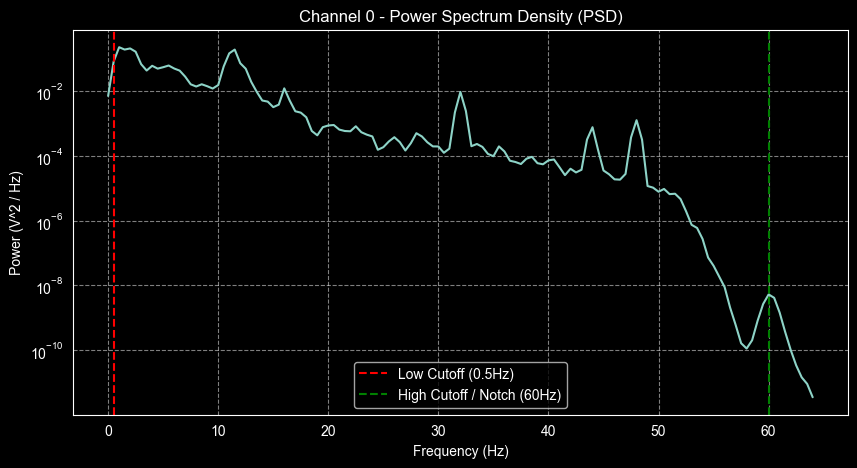

In [35]:
# İlk kanalı seçelim
channel_to_plot = 0
sig = sample_clean[channel_to_plot]
fs_new = preprocessor.target_sfreq # Artık 128 Hz (target_sfreq)

# Welch yöntemi ile güç spektrumu hesaplama
f, psd = welch(sig, fs_new, nperseg=fs_new*2)

plt.figure(figsize=(10, 5))
plt.semilogy(f, psd) # Logaritmik ölçekte daha net görünür
plt.title(f"Channel {channel_to_plot} - Power Spectrum Density (PSD)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (V^2 / Hz)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.axvline(x=0.5, color='r', linestyle='--', label='Low Cutoff (0.5Hz)')
plt.axvline(x=60, color='g', linestyle='--', label='High Cutoff / Notch (60Hz)')
plt.legend()
plt.show()

# Further parameters

In [21]:
sample_file = os.path.join(CHB_MIT_PATH, 'chb01', 'chb01_03.edf')
seizure_start = 2996  # seconds
seizure_end = 3036    # seconds

print(f"\n📂 Loading: chb01_03.edf")
print(f"   🚨 Seizure: {seizure_start}s - {seizure_end}s")

signals, channel_names, fs = deniz.load_edf_file(sample_file)
target_fs = preprocessor.target_sfreq
signals.shape

(23, 921600)

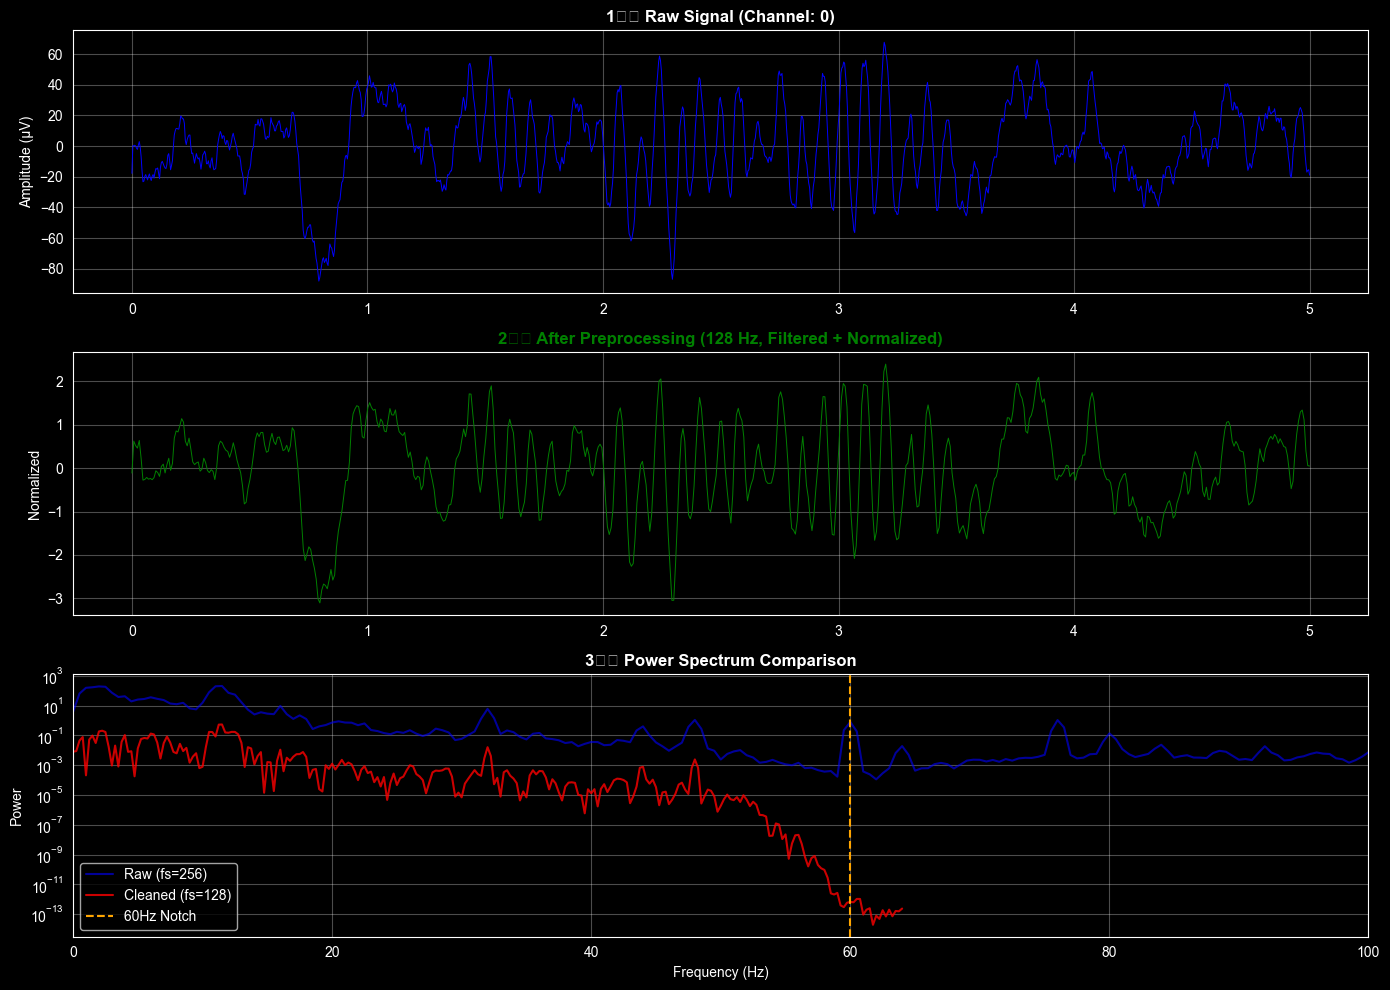

In [22]:
import matplotlib.pyplot as plt
from scipy.signal import welch
import numpy as np

# --- PARAMETRELER ---
channel_idx = 0
duration = 5  # saniye
fs_raw = preprocessor.fs           # Orijinal (256 Hz)
fs_clean = preprocessor.target_sfreq # Hedef (128 Hz)

# --- VERİ HAZIRLAMA ---
# Raw segment: Orijinal fs ile süreyi çarpıyoruz
raw_segment = signals[channel_idx, :int(duration * fs_raw)]

# Clean segment: Tüm sinyali gönderip içinden ilgili kısmı ve kanalı alıyoruz
# Preprocess içinde downsample olduğu için otomatik olarak kısalacaktır
all_cleaned = preprocessor.preprocess(signals[:, :int(duration * fs_raw)])
clean_segment = all_cleaned[channel_idx]

# Zaman eksenlerini ayrı ayrı oluşturuyoruz (çünkü örnek sayıları farklı)
time_raw = np.linspace(0, duration, len(raw_segment))
time_clean = np.linspace(0, duration, len(clean_segment))

# --- PLOT ---
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# 1. Plot: Raw Signal
axes[0].plot(time_raw, raw_segment, 'b-', linewidth=0.7)
axes[0].set_title(f'1️⃣ Raw Signal (Channel: {channel_idx})', fontweight='bold')
axes[0].set_ylabel('Amplitude (μV)')
axes[0].grid(True, alpha=0.3)

# 2. Plot: Cleaned Signal
axes[1].plot(time_clean, clean_segment, 'g-', linewidth=0.7)
axes[1].set_title(f'2️⃣ After Preprocessing ({fs_clean} Hz, Filtered + Normalized)', fontweight='bold', color='green')
axes[1].set_ylabel('Normalized')
axes[1].grid(True, alpha=0.3)

# 3. Plot: Power Spectrum Comparison
# ÖNEMLİ: Her sinyal kendi fs değeri ile analiz edilmeli
freqs_raw, psd_raw = welch(raw_segment, fs=fs_raw, nperseg=min(len(raw_segment), 512))
freqs_clean, psd_clean = welch(clean_segment, fs=fs_clean, nperseg=min(len(clean_segment), 512))

axes[2].semilogy(freqs_raw, psd_raw, 'b-', alpha=0.6, label=f'Raw (fs={fs_raw})')
axes[2].semilogy(freqs_clean, psd_clean, 'r-', alpha=0.8, label=f'Cleaned (fs={fs_clean})')
axes[2].axvline(x=preprocessor.notch_freq, color='orange', linestyle='--', label=f'{preprocessor.notch_freq}Hz Notch')

axes[2].set_title('3️⃣ Power Spectrum Comparison', fontweight='bold')
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('Power')
axes[2].set_xlim(0, 100) # EEG için 0-100Hz arası kritiktir
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
preprocessor.target_sfreq

128

In [24]:
# Configuration
new_fs = preprocessor.target_sfreq
WINDOW_SIZE = 2  # seconds
OVERLAP = 0.5  # 50% overlap
WINDOW_SAMPLES = WINDOW_SIZE * new_fs  # 2 * 128 = 256 samples
STEP_SAMPLES = int(WINDOW_SAMPLES * (1 - OVERLAP))

test_file = os.path.join(CHB_MIT_PATH, 'chb01', 'chb01_03.edf')
test_seizures = all_annotations['chb01']['chb01_03.edf']

test_windows, test_labels = deniz.extract_windows_from_file(test_file, test_seizures, preprocessor, WINDOW_SAMPLES,
                                                            STEP_SAMPLES, window_size=WINDOW_SIZE)

print(f"\n📊 Test Results (chb01_03.edf):")
print(f"   • Total windows: {len(test_windows)}")
print(f"   • Seizure windows: {np.sum(test_labels)}")
print(f"   • Normal windows: {len(test_labels) - np.sum(test_labels)}")
print(f"   • Window shape: {test_windows[0].shape}")
print(f"   • Seizure ratio: {100 * np.sum(test_labels) / len(test_labels):.2f}%")

print("\n" + "=" * 60)
print("✅ Window extraction working!")
print("=" * 60)


📊 Test Results (chb01_03.edf):
   • Total windows: 3598
   • Seizure windows: 41
   • Normal windows: 3557
   • Window shape: (23, 256)
   • Seizure ratio: 1.14%

✅ Window extraction working!


In [25]:
test_windows

array([[[-0.06718462,  0.44464567,  0.37126221, ...,  0.34518794,
          0.38988187,  0.33409419],
        [ 0.02366948, -1.31856889, -1.12458692, ...,  0.55040001,
          0.47857674,  0.05240731],
        [ 0.30958182,  0.41221   ,  0.39882966, ..., -0.0119228 ,
         -0.02574917, -0.13418024],
        ...,
        [ 0.24280951,  0.44220583,  0.44326063, ...,  1.01580281,
          1.12409485,  0.7661632 ],
        [ 0.24086997,  2.0048339 ,  1.82135947, ...,  0.4533955 ,
          0.38033418, -0.0104237 ],
        [ 0.11311035,  1.57356425,  1.40192009, ..., -0.36607939,
         -0.25737477, -0.19060651]],

       [[ 0.97781154,  1.05928025,  0.98081168, ..., -1.02429385,
         -0.5559828 ,  0.0621474 ],
        [ 0.63270913,  0.57505423,  0.55675326, ...,  1.24671301,
          1.4325263 ,  1.59606263],
        [-0.90143453, -0.96958879, -1.06054278, ...,  0.30586531,
          0.35341697,  0.26744781],
        ...,
        [-0.30352985, -0.23286728, -0.01357348, ...,  

In [26]:
np.count_nonzero(test_labels)

41

In [27]:
test_seizures

[(2996, 3036)]

In [28]:
test_file

'data-understanding/data/chb-mit\\chb01\\chb01_03.edf'